# Imports

In [165]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

import sigkernel as ksig_pde
import sigkernel_ as ksig_disc

from generators.synthetic_generators import *
from generators.ESN import ESNGenerator, ESNAsTarget
from models.trainer_ESN_LBFGS import fit_ESN_MMD_LBFGS

from loss.loss import compute_mmd_loss

from utils.kernel_helpers import median_heuristic_sigma, tune_tau_coef_for_cv
from utils.analyse_controlled_experiments import *
from utils.analyse_results import *
from utils.data import *

%load_ext autoreload
%autoreload 2

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
dtype=torch.float64

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Generators

Initialize ESN and target ESN parameters.

In [166]:
T = 100 # length of time series
N = 100  # number of samples (for target)
N_esn = 2000
target_rho = 0.99
xi_ma_theta = None # based on the ACF at the end
d = 1   # dimension of time series
W_init_std = 0.1 # standard deviation for initializing the ESN output weight matrix W

target_type = "log_sqrd_returns" # choice of target type: "returns", "log_returns", "sqrd_log_returns"

In [167]:
# Shared by both ESN
h, m, d = 500, 20, 1 # ESN hyperparameters: reservoir size, input dimension (\xi : randomness), output dimension
activation = "tanh"
quad_feedback = False # whether to include quadratic feedback in the ESN reservoir (to capture some nonlinearity and volatility clustering)
quad_gain = 0.0 # if set to 0.0 then no quadratic feedback
xi_scale = 1.0
eta_scale = 0.05

washout_len = h

A = 0.9 * torch.randn(h, h) / (h ** 0.5) # ESN reservoir weight matrix
C = torch.randn(h, m) / (m ** 0.5) # ESN input weight matrix

Create trainable ESN and target ESN instances.

In [168]:
# ESN target
A_target = A.clone()
C_target = C.clone()

# W_fixed = _W_fixed * (norm_W / torch.linalg.norm(_W_fixed)) # maybe normalize!
W_fixed = torch.randn(d, h) * float(W_init_std) 

target_esn = ESNGenerator(A_target, C_target, out_dim=d, xi_scale=xi_scale, 
                          eta_scale=eta_scale, activation=activation, 
                          target_rho=target_rho, xi_ma_theta=xi_ma_theta, 
                          quad_feedback=quad_feedback, quad_gain=quad_gain,
                          washout_len=washout_len)
with torch.no_grad():
    target_esn.W.copy_(W_fixed.to(dtype=target_esn.W.dtype, device=target_esn.W.device))
target_esn.W.requires_grad_(False)
target_generator = ESNAsTarget(target_esn, T_default=T)

In [169]:
# ESN estimator
esn = ESNGenerator(A, C, out_dim=d, xi_scale=xi_scale, 
                   eta_scale=eta_scale, activation=activation, 
                   target_rho=target_rho, xi_ma_theta=xi_ma_theta, 
                   quad_feedback=quad_feedback, quad_gain=quad_gain,
                   W_init=None, washout_len=washout_len) # if random W
                #  W_init=W_fixed) # if want to start from correct W

Small verification

In [170]:
# Generate target data  
norm_W_target = torch.linalg.norm(target_esn.W)
norm_W = torch.linalg.norm(esn.W)

print(f"Norm of ESN reservoir weights: {norm_W:.4f}")
print(f"Norm of target ESN reservoir weights: {norm_W_target:.4f}")
print(f"ESN weights:\n{esn.W[:,:10]}")
print(f"Target ESN weights:\n{target_esn.W[:,:10]}")

Norm of ESN reservoir weights: 2.2753
Norm of target ESN reservoir weights: 2.3116
ESN weights:
tensor([[-0.1003,  0.0702, -0.0722,  0.0031, -0.2317, -0.0507, -0.0907, -0.1595,
          0.0748, -0.1439]], grad_fn=<SliceBackward0>)
Target ESN weights:
tensor([[ 0.0404, -0.0615, -0.0679, -0.1002,  0.1068,  0.1212, -0.0942, -0.0643,
         -0.1301, -0.0713]])


# Kernels

In [171]:
noise = Noise("normal")
with torch.no_grad():
    Z_target_raw = target_generator.generate(N=N, noise=noise).to(device=device, dtype=dtype)
    Z_esn_raw = esn(T=T, N=N_esn).to(device=device, dtype=dtype)

# Apply the selected target transformation
eps = 1e-8

if target_type == "returns":
    Z_target = Z_target_raw
    Z_esn = Z_esn_raw
elif target_type == "log_returns":
    Z_target = torch.log1p(Z_target_raw)
    Z_esn = torch.log1p(Z_esn_raw)
elif target_type == "sqrd_log_returns":
    log_r = torch.log1p(Z_target_raw)
    Z_target = log_r ** 2
    Z_esn = torch.log1p(Z_esn_raw) ** 2
elif target_type == "log_sqrd_returns":
    Z_target = torch.log(Z_target_raw ** 2 + eps)
    Z_esn = torch.log(Z_esn_raw ** 2 + eps)

print(f"Generated data shapes: Z_target: {Z_target.shape}, Z_esn: {Z_esn.shape}")
_median_heuristic_sigma = median_heuristic_sigma(Z_target, Z_esn)
print(f"Median heuristic sigma: {_median_heuristic_sigma:.6f}")

Generated data shapes: Z_target: torch.Size([100, 100, 1]), Z_esn: torch.Size([2000, 100, 1])
Median heuristic sigma: 30.947096


In [172]:
# Define the discretized signature kernel
static_kernel_type    = 'rbf' # type of static kernel to use - rbf, rbfmix, rq, rqmix, rqlinear for
n_levels              = 10 # number of levels in the truncated signature kernel
disc_sig_kernel_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel

sig_disc_kernel = ksig_disc.kernels.get_discretized_signature_kernel(**{'static_kernel_type': static_kernel_type, 'n_levels': n_levels, 'kernel_sigma': disc_sig_kernel_sigma})

#---------------------------------
# Define the pde signature kernel
pde_sig_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel
static_kernel = ksig_pde.RBFKernel(sigma=pde_sig_sigma) # define static kernel

sig_pde_kernel = ksig_pde.SigKernel(static_kernel, dyadic_order=0)

#---------------------------------
# Define static kernel
static_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel

rbf_kernel = ksig_disc.kernels.RBFKernel(sigma=static_sigma)

#---------------------------------
# # Volterra kernel
# ld_coef = 0.7
# tau_best, cv_best, spec_best = tune_tau_coef_for_cv(X, ld_coef=ld_coef)
# tau_coef = tau_best
# volterra_kernel = ksig_disc.kernels.VolterraKernel(ld_coef=ld_coef, tau_coef=tau_coef)
# volterra_kernel.fit(X) # fitting is needed to compute lambda, tau and the normalization constant
# print(f"Best tau: {tau_best}, CV: {cv_best}")

## Choose kernel

Choose one kernel

In [173]:
# kernel = sig_disc_kernel      # discretized signature kernel
# kernel = sig_pde_kernel        # pde signature kernel
kernel = rbf_kernel           # static kernel
# kernel = volterra_kernel      # volterra kernel

Run initial MMD to check and as a baseline

In [174]:
if "sig" in kernel.__class__.__name__.lower() or "volt" in kernel.__class__.__name__.lower():
    kernel_mode = "sequential"
else:
    kernel_mode = "static"

print(f"Using kernel: {kernel.__class__.__name__} with kernel mode: {kernel_mode}")

# initial mmd:
initial_mmd = compute_mmd_loss(kernel, Z_target, Z_esn) if kernel_mode == "sequential" else compute_mmd_loss(kernel, Z_target.reshape(Z_target.shape[0], -1), Z_esn.reshape(Z_esn.shape[0], -1))
print(f"Initial MMD with {kernel.__class__.__name__} kernel: {initial_mmd:.6f}")

Using kernel: RBFKernel with kernel mode: static
Initial MMD with RBFKernel kernel: -0.000867


# Baseline MMD

In [175]:
iterations = 1000
N_small = N
N_large = N_esn
baseline_mmd = compute_baseline_mmd(target_generator,kernel,noise,iterations,N_small,N_large,kernel_mode,dtype,device, target_type)
print("Baseline MMD:", baseline_mmd)

  3%|▎         | 32/1000 [01:46<53:44,  3.33s/it]


KeyboardInterrupt: 

# Statistical Analysis Before Fitting

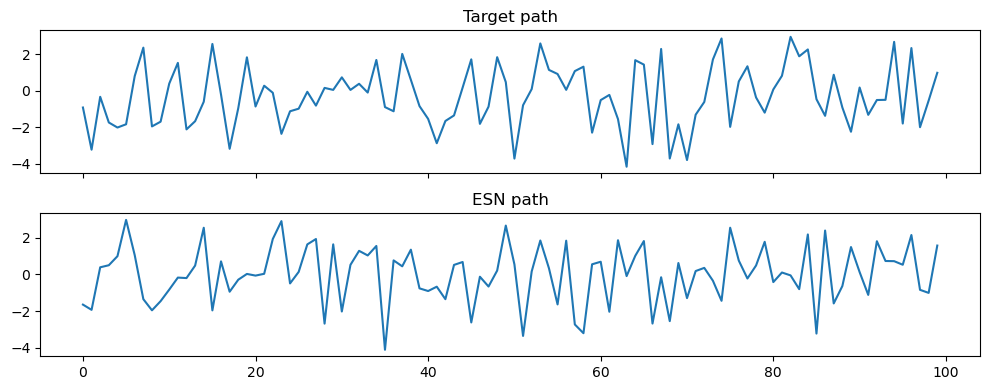

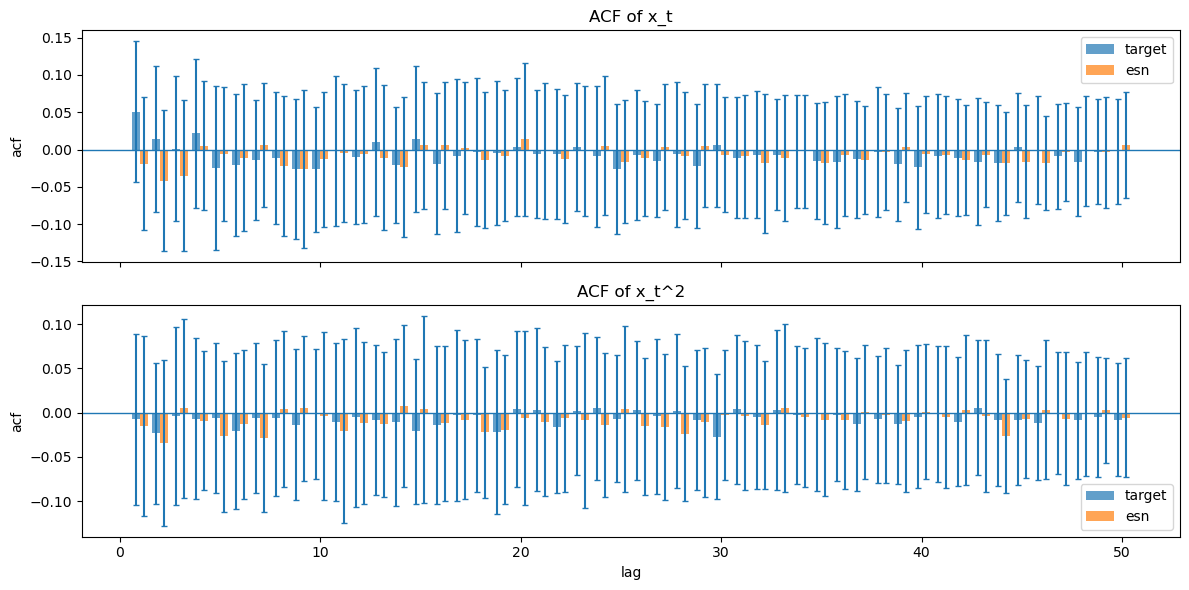

In [176]:
# run ACF analysis (plots + curves)
N_acf = 1000
T_acf = 1000
lag_acf = 50
acf_out = acf_analysis(
    Z_target_raw,
    esn,
    N=N_acf,
    T=T_acf,
    lag=lag_acf,
    component=0,
    device=device,
    dtype=dtype,
)

In [177]:
with torch.no_grad():
    Z_esn = esn(T=T, N=N_esn).to(device=device, dtype=dtype)

res = acf_two_sample_test(
    Z_target,
    Z_esn,
    lag=lag_acf,
    normalize=True,
    seed=0,
)

res_sq = acf_two_sample_test(
    Z_target,
    Z_esn,
    lag=lag_acf,
    use_squared=True,
    normalize=True,
)

res_joint = acf_two_sample_test(
    Z_target,
    Z_esn,
    lag=lag_acf,
    joint=True,
    normalize=True,
)

print("\nACF two-sample test summary")
print(f"ACF(joint) -> T_obs: {res_joint['T_obs']:.6f}, p_value: {res_joint['p_value']:.6f}")
print(f"ACF(x^2)   -> T_obs: {res_sq['T_obs']:.6f}, p_value: {res_sq['p_value']:.6f}")
print(f"ACF(x)     -> T_obs: {res['T_obs']:.6f}, p_value: {res['p_value']:.6f}")



ACF two-sample test summary
ACF(joint) -> T_obs: 1.203784, p_value: 0.995000
ACF(x^2)   -> T_obs: 0.549998, p_value: 0.980000
ACF(x)     -> T_obs: 0.653786, p_value: 0.969000


# Fit ESN

In [184]:
print(f"Using kernel: {kernel.__class__.__name__} with kernel mode: {kernel_mode}")
results = fit_ESN_MMD_LBFGS(esn = esn, 
                            Z_target = Z_target,
                            kernel = kernel, 
                            kernel_mode = kernel_mode,
                            N_model= N_esn, 
                            lead_lag=False,
                            lags=0,
                            max_iter = 2000, 
                            lr=0.1, 
                            force_float64=True,
                            verbose=True,
                            target_type=target_type
)


Using kernel: RBFKernel with kernel mode: static
MMD initial: 0.0015537266222165856
Eval 100: Loss 0.001398
Eval 200: Loss 0.001338
Eval 300: Loss 0.001287
Eval 400: Loss 0.001241
Eval 500: Loss 0.001206
Eval 600: Loss 0.001175
Eval 700: Loss 0.001149
Eval 800: Loss 0.001125
Eval 900: Loss 0.001106
Eval 1000: Loss 0.001091
Eval 1100: Loss 0.001082
Eval 1200: Loss 0.001074
Eval 1300: Loss 0.001068
Eval 1400: Loss 0.001062
Eval 1500: Loss 0.001057
Eval 1600: Loss 0.001054
Eval 1700: Loss 0.001049
Eval 1800: Loss 0.001046
Eval 1900: Loss 0.001043
Eval 2000: Loss 0.001041
Eval 2100: Loss 0.001038
MMD final: 0.0010380008625811006


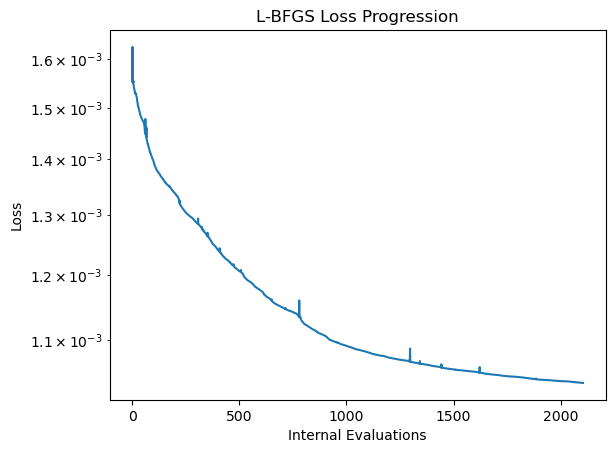

In [185]:
loss_history = results['loss_history']
plt.plot(loss_history)
plt.xlabel('Internal Evaluations')
plt.ylabel('Loss')
plt.title('L-BFGS Loss Progression')
plt.yscale('log') # Useful if loss drops several orders of magnitude
plt.show()

# Statistical Analysis After Fitting

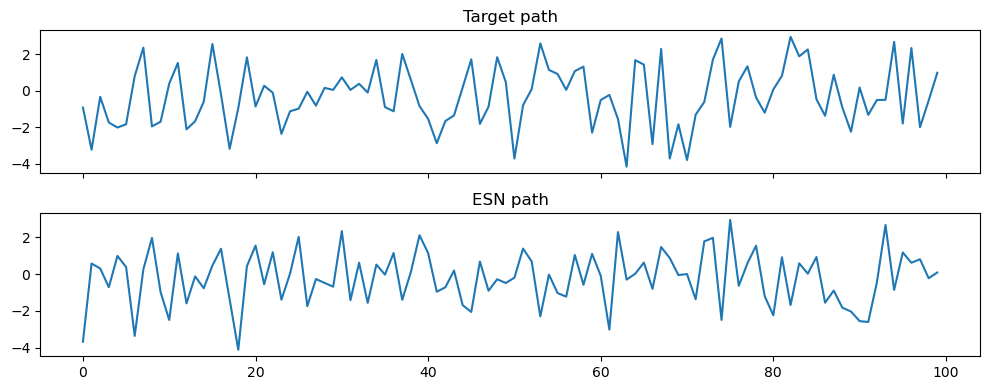

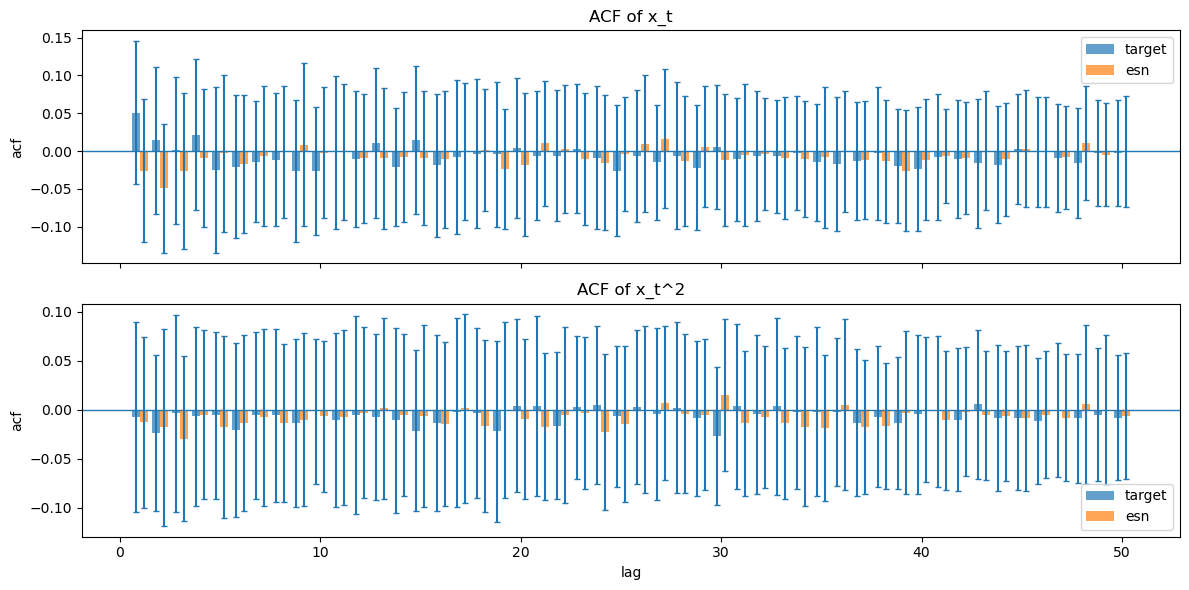

In [186]:
# run ACF analysis (plots + curves)
N_acf = 1000
T_acf = 1000
lag_acf = 50
acf_out = acf_analysis(
    Z_target_raw,
    esn,
    N=N_acf,
    T=T_acf,
    lag=lag_acf,
    component=0,
    device=device,
    dtype=dtype,
)

In [187]:
with torch.no_grad():
    Z_esn = esn(T=T, N=N_esn).to(device=device, dtype=dtype)

res = acf_two_sample_test(
    Z_target_raw,
    Z_esn,
    lag=lag_acf,
    normalize=True,
    seed=0,
)

res_sq = acf_two_sample_test(
    Z_target_raw,
    Z_esn,
    lag=lag_acf,
    use_squared=True,
    normalize=True,
)

res_joint = acf_two_sample_test(
    Z_target_raw,
    Z_esn,
    lag=lag_acf,
    joint=True,
    normalize=True,
)

print("\nACF two-sample test summary")
print(f"ACF(x)     -> T_obs: {res['T_obs']:.6f}, p_value: {res['p_value']:.6f}")
print(f"ACF(x^2)   -> T_obs: {res_sq['T_obs']:.6f}, p_value: {res_sq['p_value']:.6f}")
print(f"ACF(joint) -> T_obs: {res_joint['T_obs']:.6f}, p_value: {res_joint['p_value']:.6f}")



ACF two-sample test summary
ACF(x)     -> T_obs: 1.864194, p_value: 0.000000
ACF(x^2)   -> T_obs: 0.431900, p_value: 1.000000
ACF(joint) -> T_obs: 2.296093, p_value: 0.157000


E[W_fixed^2]          = 0.0106872
MSE(W_fit, W_fixed)   = 0.0216132
relative MSE          = 2.02235
||W_fixed||_F         = 2.31162
||W_fit||_F           = 2.26827
||W_fit-W_fixed||_F   = 3.28734
relative Frobenius    = 1.42209
Corr(flattened)       = -0.0309397
W_fit[:5]             = [-0.09632788  0.06811248 -0.07147257  0.0023276  -0.23191992]
W_fixed[:5]           = [ 0.04040841 -0.0614893  -0.06786671 -0.10021913  0.10684215]


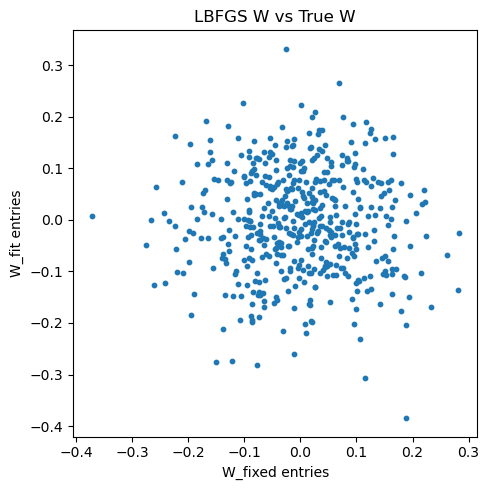

In [188]:
stats = compare_Ws(
    esn = esn,
    W_fixed=W_fixed,
    title="LBFGS W vs True W",
    scatter=True,
)